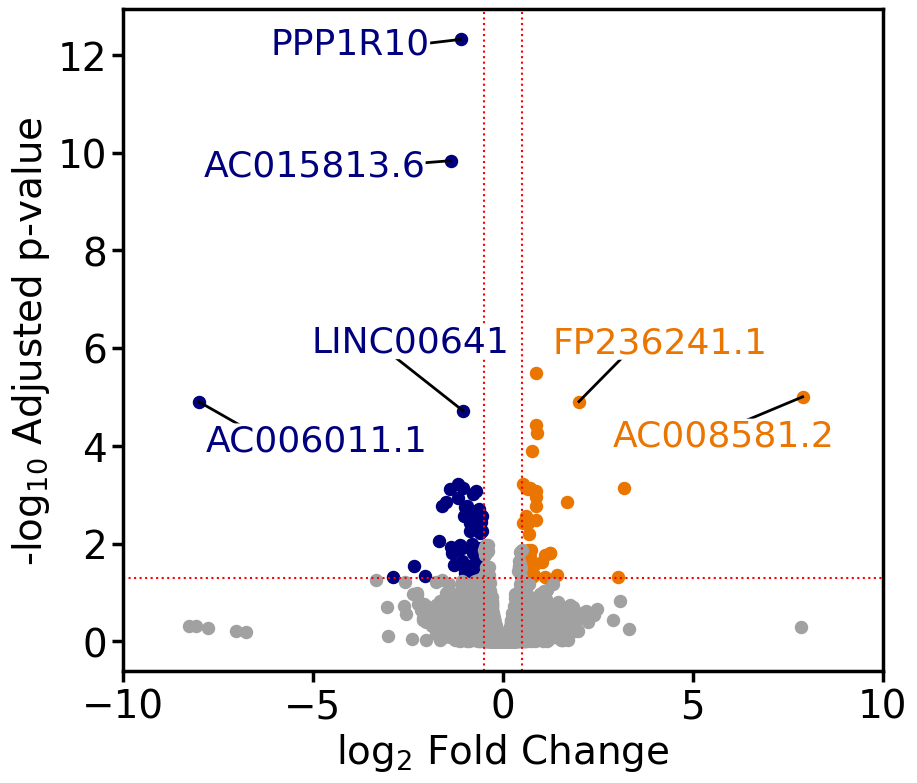

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_optimal_thresholds(df):
    left_side = df[df['log2FoldChange'] < 0].sort_values(by='padj')
    right_side = df[df['log2FoldChange'] > 0].sort_values(by='padj')
    optimal_padj_left = left_side.iloc[min(5, len(left_side) - 1)]['padj']
    optimal_padj_right = right_side.iloc[min(5, len(right_side) - 1)]['padj']
    return min(optimal_padj_left, optimal_padj_right)

def generate_manual_adjusted_volcano_plot(df, title, padj_threshold, genes_to_label):
    fig, ax = plt.subplots(figsize=(9.8, 8.6))

    # Manually assign colors to each category
    color_orange = '#EA7500'
    color_blue = '#00007F'
    color_grey = '#a1a1a1'

    # Plot each category manually
    # Points with log2FoldChange > 0.5 and -log10(padj) > 1.3 (Orange)
    df_orange = df[(df['log2FoldChange'] > 0.5) & (-np.log10(df['padj']) > 1.3)]
    ax.scatter(df_orange['log2FoldChange'], -np.log10(df_orange['padj']), color=color_orange, s=75, label='Upregulated')

    # Points with log2FoldChange < -0.5 and -log10(padj) > 1.3 (Blue)
    df_blue = df[(df['log2FoldChange'] < -0.5) & (-np.log10(df['padj']) > 1.3)]
    ax.scatter(df_blue['log2FoldChange'], -np.log10(df_blue['padj']), color=color_blue, s=75, label='Downregulated')

    # All other points (Grey)
    df_grey = df[~((df['log2FoldChange'] > 0.5) & (-np.log10(df['padj']) > 1.3)) & 
                 ~((df['log2FoldChange'] < -0.5) & (-np.log10(df['padj']) > 1.3))]
    ax.scatter(df_grey['log2FoldChange'], -np.log10(df_grey['padj']), color=color_grey, s=75, label='Not significant')

    # Add labels for the selected genes with adjusted positions
    texts = []
    for gene_name in genes_to_label:
        subset = df[df['gene_name'] == gene_name]
        for i in range(subset.shape[0]):
            initial_x = subset['log2FoldChange'].values[i]
            initial_y = -np.log10(subset['padj']).values[i]

            # Adjust label positions based on gene name
            if gene_name == 'AC006011.1':
                initial_x += 0.2
                initial_y += -1
            if gene_name == 'PPP1R10':
                initial_x += -5
                initial_y += -0.3
            if gene_name == 'AC015813.6':
                initial_x += -6.5
                initial_y += -0.3
            if gene_name == 'LINC00641':
                initial_x += -4
                initial_y += 1.2
            if gene_name == 'FP236241.1':
                initial_x += -0.7
                initial_y += 1
            if gene_name == 'AC008581.2':
                initial_x += -5
                initial_y += -1

            # Determine the color of the text based on the point color
            if initial_x > 0.5 and initial_y > 1.3:
                text_color = color_orange
            elif initial_x < -0.5 and initial_y > 1.3:
                text_color = color_blue
            else:
                text_color = color_grey

            texts.append(ax.text(initial_x, initial_y, gene_name, color=text_color, fontsize=26, 
                                 bbox=dict(facecolor='white', linewidth=1, edgecolor='none', boxstyle='round,pad=0.001')))

    # Add lines for the specified genes
    for text in texts:
        gene_name = text.get_text()
        subset = df[df['gene_name'] == gene_name]
        for i in range(subset.shape[0]):
            point_x = subset['log2FoldChange'].values[i]
            point_y = -np.log10(subset['padj'].values[i])
            
            label_x = text.get_position()[0] + 2
            label_y = text.get_position()[1] + 0.025
            
            plt.plot([point_x, label_x], [point_y, label_y], 'k-', linewidth=2)
    
    plt.xlabel(r'log$_2$ Fold Change', fontsize=28)
    plt.ylabel(r'-log$_{10}$ Adjusted p-value', fontsize=28)
    plt.tick_params(axis='both', colors='black', width=2.5, length=8, labelsize=28)
    plt.xticks(fontsize=28)
    plt.yticks(fontsize=28)
    plt.xlim(-10, 10)
    plt.grid(False)
    # Set axis linewidth
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.5)


    # Add vertical red dotted lines at x = -0.5 and x = 0.5
    plt.axvline(x=-0.5, color='red', linestyle=':', linewidth=1.5)
    plt.axvline(x=0.5, color='red', linestyle=':', linewidth=1.5)

    # Add horizontal red dotted line at y = 1.3 with x domain -5 to 0
    plt.axhline(y=1.3, color='red', linestyle=':', linewidth=1.5)
    plt.savefig('RNA-seq QC6352 24hrs.jpeg', format='jpeg', dpi=72, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Read the 24-hour data
df_24hrs = pd.read_excel(r"C:\Users\sterl\Desktop\24hrs full.xlsx")
optimal_padj_24hrs = find_optimal_thresholds(df_24hrs)
genes_to_label = ['AC006011.1', 'PPP1R10', 'AC015813.6', 'LINC00641', 'FP236241.1', 'AC008581.2']

# Generate the plot
generate_manual_adjusted_volcano_plot(df_24hrs, 'Final Adjusted Volcano Plot for Control_vs_24hrs', optimal_padj_24hrs, genes_to_label)


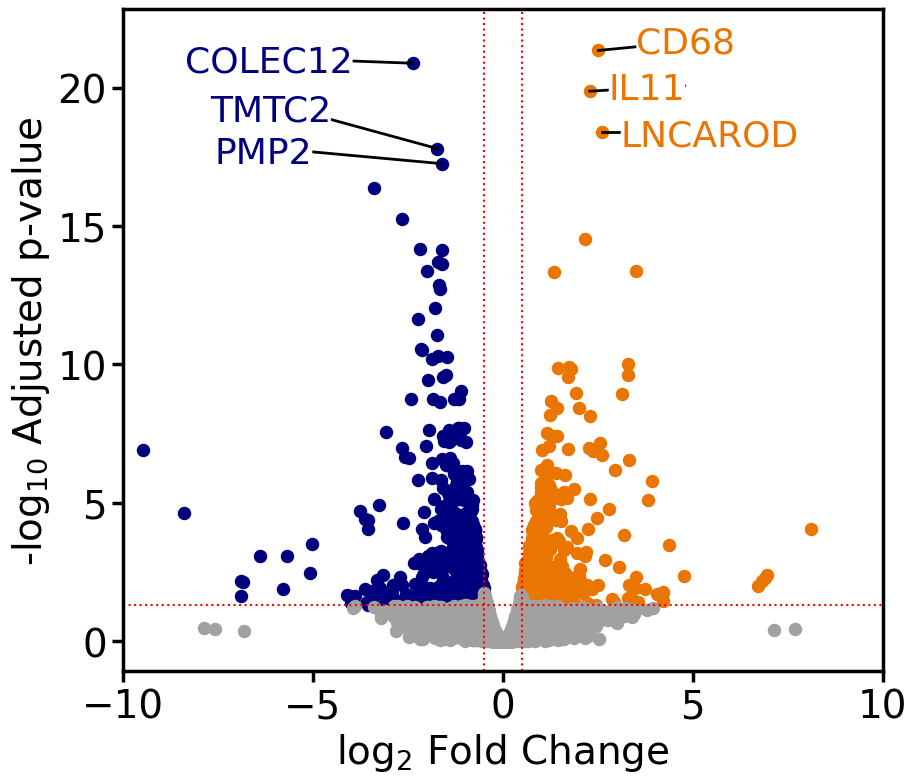

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel(r"C:\Users\sterl\Desktop\72hrs full.xlsx")

def find_optimal_thresholds(df):
    left_side = df[df['log2FoldChange'] < 0].sort_values(by='padj')
    right_side = df[df['log2FoldChange'] > 0].sort_values(by='padj')
    optimal_padj_left = left_side.iloc[min(5, len(left_side) - 1)]['padj']
    optimal_padj_right = right_side.iloc[min(5, len(right_side) - 1)]['padj']
    return min(optimal_padj_left, optimal_padj_right)

def generate_manual_adjusted_volcano_plot(df, title, padj_threshold, genes_to_label):
    fig, ax = plt.subplots(figsize=(9.8, 8.6))

    # Manually assign colors to each category
    color_orange = '#EA7500'
    color_blue = '#00007F'
    color_grey = '#a1a1a1'

    # Plot each category manually
    # Points with log2FoldChange > 0.5 and -log10(padj) > 1.3 (Orange)
    df_orange = df[(df['log2FoldChange'] > 0.5) & (-np.log10(df['padj']) > 1.3)]
    ax.scatter(df_orange['log2FoldChange'], -np.log10(df_orange['padj']), color=color_orange, s=75, label='Upregulated')

    # Points with log2FoldChange < -0.5 and -log10(padj) > 1.3 (Blue)
    df_blue = df[(df['log2FoldChange'] < -0.5) & (-np.log10(df['padj']) > 1.3)]
    ax.scatter(df_blue['log2FoldChange'], -np.log10(df_blue['padj']), color=color_blue, s=75, label='Downregulated')

    # All other points (Grey)
    df_grey = df[~((df['log2FoldChange'] > 0.5) & (-np.log10(df['padj']) > 1.3)) & 
                 ~((df['log2FoldChange'] < -0.5) & (-np.log10(df['padj']) > 1.3))]
    ax.scatter(df_grey['log2FoldChange'], -np.log10(df_grey['padj']), color=color_grey, s=75, label='Not significant')

    # Add labels for the selected genes with adjusted positions
    texts = []
    for gene_name in genes_to_label:
        subset = df[df['gene_name'] == gene_name]
        for i in range(subset.shape[0]):
            initial_x = subset['log2FoldChange'].values[i]
            initial_y = -np.log10(subset['padj']).values[i]

            # Adjust label positions based on gene name
            if gene_name == 'CD68':
                initial_x += 1
                initial_y += -0.1
            if gene_name == 'COLEC12':
                initial_x += -6
                initial_y += -0.3
            if gene_name == 'IL11':
                initial_x += 0.5
                initial_y += -0.3
            if gene_name == 'LNCAROD':
                initial_x += 0.5
                initial_y += -0.5
            if gene_name == 'TMTC2':
                initial_x += -6
                initial_y += 1
            if gene_name == 'PMP2':
                initial_x += -6
                initial_y += 0

            # Determine the color of the text based on the point color
            if initial_x > 0.5 and initial_y > 1.3:
                text_color = color_orange
            elif initial_x < -0.5 and initial_y > 1.3:
                text_color = color_blue
            else:
                text_color = color_grey

            texts.append(ax.text(initial_x, initial_y, gene_name, color=text_color, fontsize=26, 
                                 bbox=dict(facecolor='white', linewidth=1, edgecolor='none', boxstyle='round,pad=0.001')))

    # Add lines for the specified genes
    for text in texts:
        gene_name = text.get_text()
        subset = df[df['gene_name'] == gene_name]
        for i in range(subset.shape[0]):
            point_x = subset['log2FoldChange'].values[i]
            point_y = -np.log10(subset['padj']).values[i]
            
            label_x = text.get_position()[0] + 2
            label_y = text.get_position()[1] + 0.5
            
            plt.plot([point_x, label_x], [point_y, label_y], 'k-', linewidth=2)
    
    plt.xlabel(r'log$_2$ Fold Change', fontsize=28)
    plt.ylabel(r'-log$_{10}$ Adjusted p-value', fontsize=28)
    plt.tick_params(axis='both', colors='black', width=2.5, length=8, labelsize=28)
    plt.xticks(fontsize=28)
    plt.yticks(fontsize=28)
    plt.xlim(-10, 10)
    plt.grid(False)

    # Set axis linewidth
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.5)

    # Add vertical red dotted lines at x = -0.5 and x = 0.5
    plt.axvline(x=-0.5, color='red', linestyle=':', linewidth=1.5)
    plt.axvline(x=0.5, color='red', linestyle=':', linewidth=1.5)

    # Add horizontal red dotted line at y = 1.3 with x domain -5 to 0
    plt.axhline(y=1.3, color='red', linestyle=':', linewidth=1.5)

    # Save the plot with the correct aesthetics
    plt.savefig('RNA-seq QC6352 72hrs.jpeg', format='jpeg', dpi=72, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()

# Read the 72-hour data
df_72hrs = pd.read_excel(r"C:\Users\sterl\Desktop\72hrs full.xlsx")
optimal_padj_72hrs = find_optimal_thresholds(df_72hrs)
genes_to_label = ['CD68', 'COLEC12', 'IL11', 'LNCAROD', 'TMTC2', 'PMP2']

# Generate the plot
generate_manual_adjusted_volcano_plot(df_72hrs, 'Final Adjusted Volcano Plot for Control_vs_72hrs', optimal_padj_72hrs, genes_to_label)


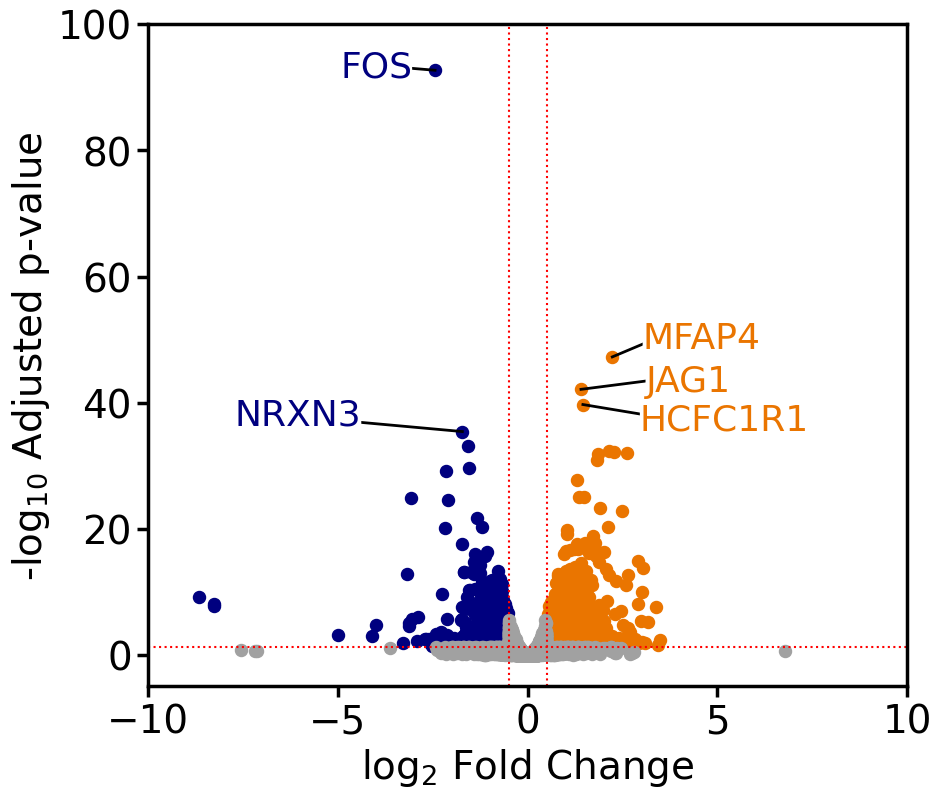

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel(r"C:\Users\sterl\Desktop\120hrs full.xlsx")

def find_optimal_thresholds(df):
    left_side = df[df['log2FoldChange'] < 0].sort_values(by='padj')
    right_side = df[df['log2FoldChange'] > 0].sort_values(by ='padj')
    optimal_padj_left = left_side.iloc[min(5, len(left_side) - 1)]['padj']
    optimal_padj_right = right_side.iloc[min(5, len(right_side) - 1)]['padj']
    return min(optimal_padj_left, optimal_padj_right)

def generate_manual_adjusted_volcano_plot(df, title, padj_threshold, genes_to_label):
    fig, ax = plt.subplots(figsize=(9.8, 8.6))

    # Manually assign colors to each category
    color_orange = '#EA7500'
    color_blue = '#00007F'
    color_grey = '#a1a1a1'

    # Plot each category manually
    # Points with log2FoldChange > 0.5 and -log10(padj) > 1.3 (Orange)
    df_orange = df[(df['log2FoldChange'] > 0.5) & (-np.log10(df['padj']) > 1.3)]
    ax.scatter(df_orange['log2FoldChange'], -np.log10(df_orange['padj']), color=color_orange, s=75, label='Upregulated')

    # Points with log2FoldChange < -0.5 and -log10(padj) > 1.3 (Blue)
    df_blue = df[(df['log2FoldChange'] < -0.5) & (-np.log10(df['padj']) > 1.3)]
    ax.scatter(df_blue['log2FoldChange'], -np.log10(df_blue['padj']), color=color_blue, s=75, label='Downregulated')

    # All other points (Grey)
    df_grey = df[~((df['log2FoldChange'] > 0.5) & (-np.log10(df['padj']) > 1.3)) & 
                 ~((df['log2FoldChange'] < -0.5) & (-np.log10(df['padj']) > 1.3))]
    ax.scatter(df_grey['log2FoldChange'], -np.log10(df_grey['padj']), color=color_grey, s=75, label='Not significant')

    # Add labels for the selected genes with adjusted positions
    texts = []
    for gene_name in genes_to_label:
        subset = df[df['gene_name'] == gene_name]
        for i in range(subset.shape[0]):
            initial_x = subset['log2FoldChange'].values[i]
            initial_y = -np.log10(subset['padj']).values[i]

            # Adjust label positions based on gene name
            if gene_name == 'FOS':
                initial_x += -2.5
                initial_y += -1
            if gene_name == 'MFAP4':
                initial_x += 0.8
                initial_y += 1.3
            if gene_name == 'JAG1':
                initial_x += 1.7
                initial_y += -0.3
            if gene_name == 'HCFC1R1':
                initial_x += 1.5
                initial_y += -4
            if gene_name == 'NRXN3':
                initial_x += -6
                initial_y += 1

            # Determine the color of the text based on the point color
            if initial_x > 0.5 and initial_y > 1.3:
                text_color = color_orange
            elif initial_x < -0.5 and initial_y > 1.3:
                text_color = color_blue
            else:
                text_color = color_grey

            texts.append(ax.text(initial_x, initial_y, gene_name, color=text_color, fontsize=26, 
                                 bbox=dict(facecolor='white', linewidth=1, edgecolor='none', boxstyle='round,pad=0.001')))

    # Add lines for the specified genes
    for text in texts:
        gene_name = text.get_text()
        subset = df[df['gene_name'] == gene_name]
        for i in range(subset.shape[0]):
            point_x = subset['log2FoldChange'].values[i]
            point_y = -np.log10(subset['padj']).values[i]
            
            label_x = text.get_position()[0] + 0.5
            label_y = text.get_position()[1] + 2
            
            plt.plot([point_x, label_x], [point_y, label_y], 'k-', linewidth=2)
    
    plt.xlabel(r'log$_2$ Fold Change', fontsize=28)
    plt.ylabel(r'-log$_{10}$ Adjusted p-value', fontsize=28)
    plt.tick_params(axis='both', colors='black', width=2.5, length=8, labelsize=28)
    plt.xticks(fontsize=28)
    plt.yticks(fontsize=28)
    plt.xlim(-10, 10)
    plt.ylim(-5, 100)
    plt.grid(False)

    # Set axis linewidth
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.5)

    # Add vertical red dotted lines at x = -0.5 and x = 0.5
    plt.axvline(x=-0.5, color='red', linestyle=':', linewidth=1.5)
    plt.axvline(x=0.5, color='red', linestyle=':', linewidth=1.5)

    # Add horizontal red dotted line at y = 1.3 with x domain -5 to 0
    plt.axhline(y=1.3, color='red', linestyle=':', linewidth=1.5)

    # Save the plot with the correct aesthetics
    plt.savefig('RNA-seq QC6352 120hrs.jpeg', format='jpeg', dpi=72, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()

# Read the 120-hour data
df_120hrs = pd.read_excel(r"C:\Users\sterl\Desktop\120hrs full.xlsx")
optimal_padj_120hrs = find_optimal_thresholds(df_120hrs)
genes_to_label = ['FOS', 'MFAP4', 'JAG1', 'HCFC1R1', 'NRXN3']

# Generate the plot
generate_manual_adjusted_volcano_plot(df_120hrs, 'Final Adjusted Volcano Plot for Control_vs_120hrs', optimal_padj_120hrs, genes_to_label)
